In [138]:
import numpy as np
from matplotlib import pyplot as plt, patches
import random

In [139]:
width = 1500
height = 1500
cutout_left = 1000
cutout_top = 500

walls = [
    (0, height),
    (width, height),
    (width, cutout_top),
    (cutout_left, cutout_top),
    (cutout_left, 0),
    (0, 0)
]

In [140]:
poses = np.random.normal([250, 300], [2, 2], size=(400, 2))

In [141]:
# create a line for a motion vector
motion_angle = 30
motion_distance = 300

distance_affects_distance_uncertainty = 0.08
distance_affect_angle_uncertainty = 0.12
angle_affects_angle_uncertainty = 0.09
angle_affect_distance_uncertainty = 0.08

In [142]:
def get_random_sample(mean, scale):
    # return mean + (random.uniform(-scale, scale) + random.uniform(-scale, scale)) / 2
    return np.random.normal(mean, scale/3)

In [143]:
rotation_scale = angle_affects_angle_uncertainty * abs(motion_angle) + distance_affect_angle_uncertainty * abs(motion_distance)
translation_scale = distance_affects_distance_uncertainty * abs(motion_distance) + angle_affect_distance_uncertainty * abs(motion_angle)

motion_rotation = np.array([get_random_sample(motion_angle, rotation_scale) for _ in range(poses.shape[0])])
motion_translation = np.array([get_random_sample(motion_distance, translation_scale) for _ in range(poses.shape[0])])

In [144]:
new_poses = np.zeros_like(poses)
new_poses[:, 0] = poses[:, 0] + motion_translation * np.cos(np.radians(motion_rotation))
new_poses[:, 1] = poses[:, 1] + motion_translation * np.sin(np.radians(motion_rotation))

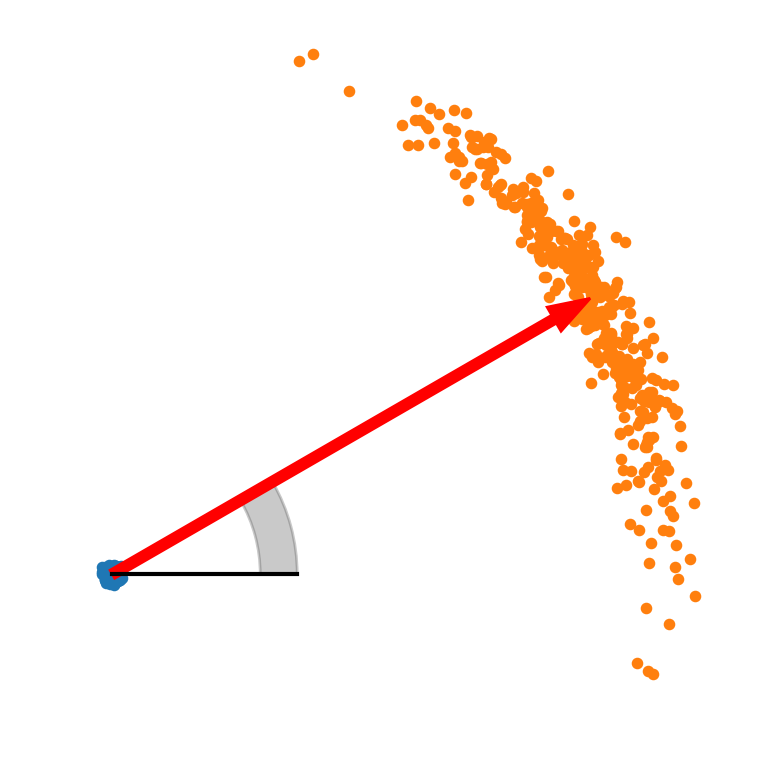

In [145]:
fig, ax = plt.subplots()
# Use smaller dots for the scatter plots
ax.scatter(poses[:, 0], poses[:, 1], s=10)
ax.scatter(new_poses[:, 0], new_poses[:, 1], s=10)
# plot the horizontal line under the angle 
ax.plot([250, 250+100], [300, 300], color="black")
# # label plot axes with mm
# ax.set_xlabel("mm")
# ax.set_ylabel("mm")
# Hide axes lines, scales and tickers
ax.axis('off')
# Show the angle
angle = patches.Wedge((250, 300), 100, 0, motion_angle, width=20, color=(0.3, 0.3, 0.3, 0.3))
ax.add_patch(angle)
# ax.text(370, 330, f"{motion_angle}°", horizontalalignment="center", verticalalignment="center", 
#   fontsize="x-large")
# Plot the motion line
motion_line_length = motion_distance * 0.92
motion_line = np.array([[250, 300], 
  [motion_line_length * np.cos(np.radians(motion_angle)), motion_line_length * np.sin(np.radians(motion_angle))]])
ax.arrow(*motion_line[0], *motion_line[1], color="red", width=5)
# Make the aspect ratio equal
ax.set_aspect('equal', adjustable='box')
# Make the axis limits equal 
ax.set_xlim(200, 600)
ax.set_ylim(200, 600)
# Set a higher resolution for the output image
fig.set_dpi(200)
plt.show()